# Model 1: Random Forest
Designed by: Gyeonghwan Noh

Following the CAB420 Prac 3 Q2 approach, four Random Forest configurations
are trained and compared. Because of the 8.77x class imbalance,
`class_weight='balanced_subsample'` is applied to **all four** models -
fair handling of the minority classes is a baseline requirement, not a
variable to tune. What varies between the four models is tree capacity
(`max_depth` and `n_estimators`), so the comparison isolates the effect
of model capacity.

The four configurations are:
1. **Shallow** - `max_depth=4`, n=100
2. **Deep** - `max_depth=32`, n=100 (to observe overfitting)
3. **Moderate** - `max_depth=8`, n=100
4. **Tuned** - `max_depth=20`, n=300 (final model)

In [1]:
# Imports
import sys
import time
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from skimage.feature import hog
from skimage.color import rgb2gray

from sklearn.ensemble import RandomForestClassifier

sys.path.append("..")
from shared_utils import (
    PROJECT_ROOT,
    load_data,
    eval_model,
    save_metrics,
    extract_hog_batch,
)

In [15]:
# Configurations

# Reproducibility
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# Directory to save figures
FIGURES_DIR = PROJECT_ROOT / "random_forest" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
# Data Loading
data = load_data()

train_paths = data["train_paths"]
val_paths = data["val_paths"]
test_paths = data["test_paths"]

train_labels = data["train_labels"]
val_labels = data["val_labels"]
test_labels = data["test_labels"]

class_list = data["class_list"]

RANDOM_STATE = 42

print("Train:", len(train_paths))
print("Val:", len(val_paths))
print("Test:", len(test_paths))
print("Classes:", class_list)

print()
print("Example train image:")
print(train_paths[0])
print("Exists:", Path(train_paths[0]).exists())

Train: 10859
Val: 2328
Test: 2328
Classes: ['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass']

Example train image:
/home/n11902736/cab420/WasteClassification/data/garbage_classification/clothes/clothes3810.jpg
Exists: True


## HOG feature extraction

In [4]:
# Extract HOG for all three splits
X_train = extract_hog_batch(train_paths, 'train')
X_val = extract_hog_batch(val_paths, 'val')
X_test = extract_hog_batch(test_paths, 'test')

# Labels stay as they are
Y_train = train_labels
Y_val = val_labels
Y_test = test_labels

print()
print(f'X_train: {X_train.shape}')
print(f'X_val: {X_val.shape}')
print(f'X_test: {X_test.shape}')
print(f'HOG feature dimension: {X_train.shape[1]}')

loading cached features: hog_train_size128x128_ori9_ppc16x16_cpb2x2.npz
loading cached features: hog_val_size128x128_ori9_ppc16x16_cpb2x2.npz
loading cached features: hog_test_size128x128_ori9_ppc16x16_cpb2x2.npz

X_train: (10859, 1764)
X_val: (2328, 1764)
X_test: (2328, 1764)
HOG feature dimension: 1764


## RF1 - Shallow

RF 1: Shallow depth=4 n=100
---------------------------
Training time     : 3.51s
Inference time    : 0.024s
Time per sample   : 0.010ms
---------------------------
              precision    recall  f1-score   support

     battery     0.3084    0.7254    0.4328       142
  biological     0.2634    0.3649    0.3059       148
 brown-glass     0.2066    0.2747    0.2358        91
   cardboard     0.2000    0.0075    0.0144       134
     clothes     0.7290    0.8348    0.7783       799
 green-glass     0.3200    0.0851    0.1345        94
       metal     0.2837    0.3478    0.3125       115
       paper     0.2325    0.5287    0.3230       157
     plastic     0.4111    0.2846    0.3364       130
       shoes     0.5116    0.0741    0.1294       297
       trash     0.4070    0.3333    0.3665       105
 white-glass     0.3333    0.0172    0.0328       116

    accuracy                         0.4626      2328
   macro avg     0.3506    0.3232    0.2835      2328
weighted avg     0.4711

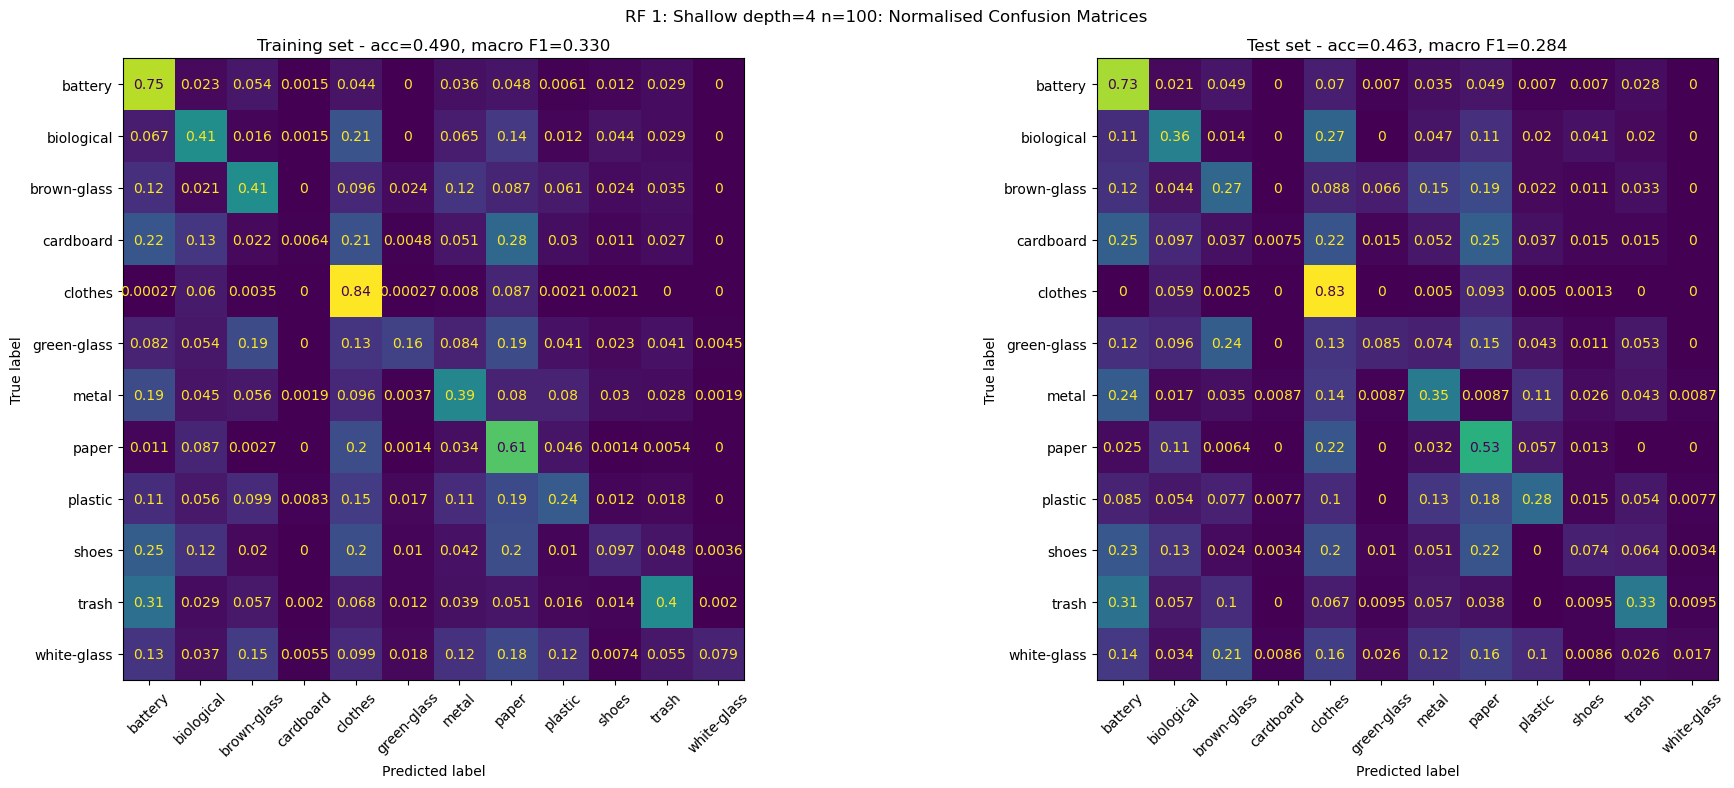

In [5]:
t0 = time.perf_counter()

rf1 = RandomForestClassifier(
    n_estimators=100,
    max_depth=4,
    random_state=RANDOM_STATE,
    class_weight="balanced_subsample",
    n_jobs=-1,
).fit(X_train, Y_train)

train_time_1 = time.perf_counter() - t0

# Predictions
train_pred_1 = rf1.predict(X_train)

t0 = time.perf_counter()
test_pred_1 = rf1.predict(X_test)
infer_time_1 = time.perf_counter() - t0

result_1 = eval_model(
    Y_test,
    test_pred_1,
    class_list,
    model_name="RF 1: Shallow depth=4 n=100",
    y_train=Y_train,
    train_pred=train_pred_1,
    train_time=train_time_1,
    inference_time=infer_time_1,
)

## RF2 - Deep

RF 2: Deep depth=32 n=100
-------------------------
Training time     : 10.48s
Inference time    : 0.025s
Time per sample   : 0.011ms
-------------------------
              precision    recall  f1-score   support

     battery     0.6051    0.6690    0.6355       142
  biological     0.5128    0.1351    0.2139       148
 brown-glass     0.5122    0.2308    0.3182        91
   cardboard     0.6429    0.0672    0.1216       134
     clothes     0.5139    0.9975    0.6783       799
 green-glass     0.5806    0.1915    0.2880        94
       metal     0.4400    0.1913    0.2667       115
       paper     0.8462    0.2803    0.4211       157
     plastic     0.5849    0.2385    0.3388       130
       shoes     0.5391    0.4175    0.4706       297
       trash     0.7164    0.4571    0.5581       105
 white-glass     0.5349    0.1983    0.2893       116

    accuracy                         0.5378      2328
   macro avg     0.5857    0.3395    0.3833      2328
weighted avg     0.5656    0

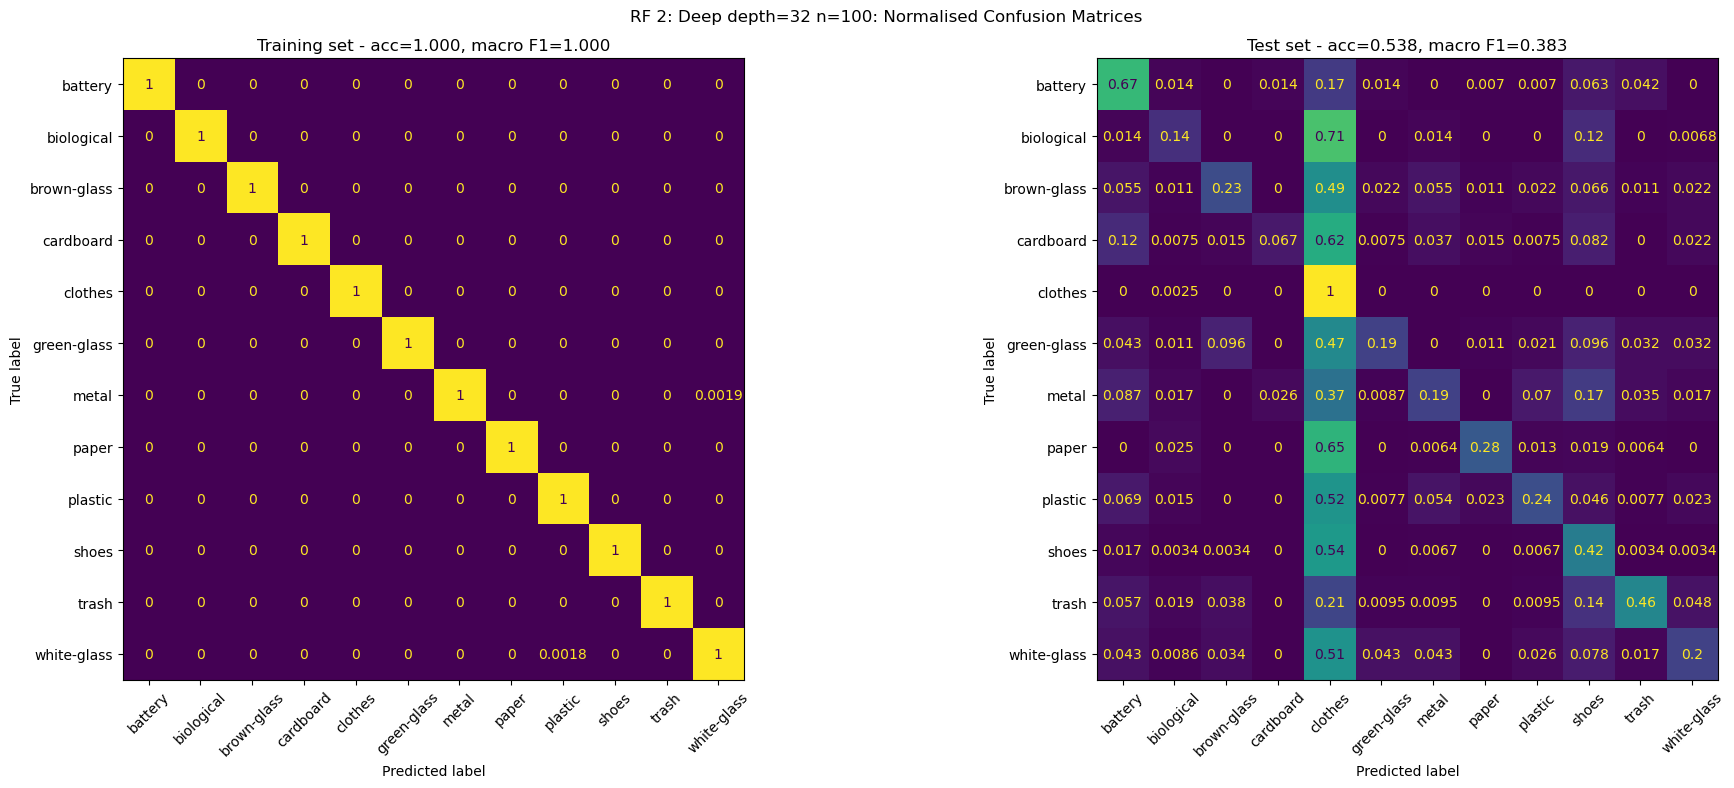

In [6]:
t0 = time.perf_counter()

rf2 = RandomForestClassifier(
    n_estimators=100,
    max_depth=32,
    random_state=RANDOM_STATE,
    class_weight="balanced_subsample",
    n_jobs=-1,
).fit(X_train, Y_train)

train_time_2 = time.perf_counter() - t0

# Predictions
train_pred_2 = rf2.predict(X_train)

t0 = time.perf_counter()
test_pred_2 = rf2.predict(X_test)
infer_time_2 = time.perf_counter() - t0

result_2 = eval_model(
    Y_test,
    test_pred_2,
    class_list,
    model_name="RF 2: Deep depth=32 n=100",
    y_train=Y_train,
    train_pred=train_pred_2,
    train_time=train_time_2,
    inference_time=infer_time_2,
)

## RF3 - Moderate

RF 3: Moderate depth=8 n=100
----------------------------
Training time     : 6.19s
Inference time    : 0.024s
Time per sample   : 0.010ms
----------------------------
              precision    recall  f1-score   support

     battery     0.4928    0.7183    0.5845       142
  biological     0.2635    0.5270    0.3514       148
 brown-glass     0.3030    0.3297    0.3158        91
   cardboard     0.3333    0.0746    0.1220       134
     clothes     0.7936    0.8323    0.8125       799
 green-glass     0.4364    0.2553    0.3221        94
       metal     0.3306    0.3565    0.3431       115
       paper     0.3806    0.5987    0.4653       157
     plastic     0.4462    0.4462    0.4462       130
       shoes     0.6234    0.3232    0.4257       297
       trash     0.4386    0.4762    0.4566       105
 white-glass     0.5000    0.1466    0.2267       116

    accuracy                         0.5434      2328
   macro avg     0.4452    0.4237    0.4060      2328
weighted avg     0.5

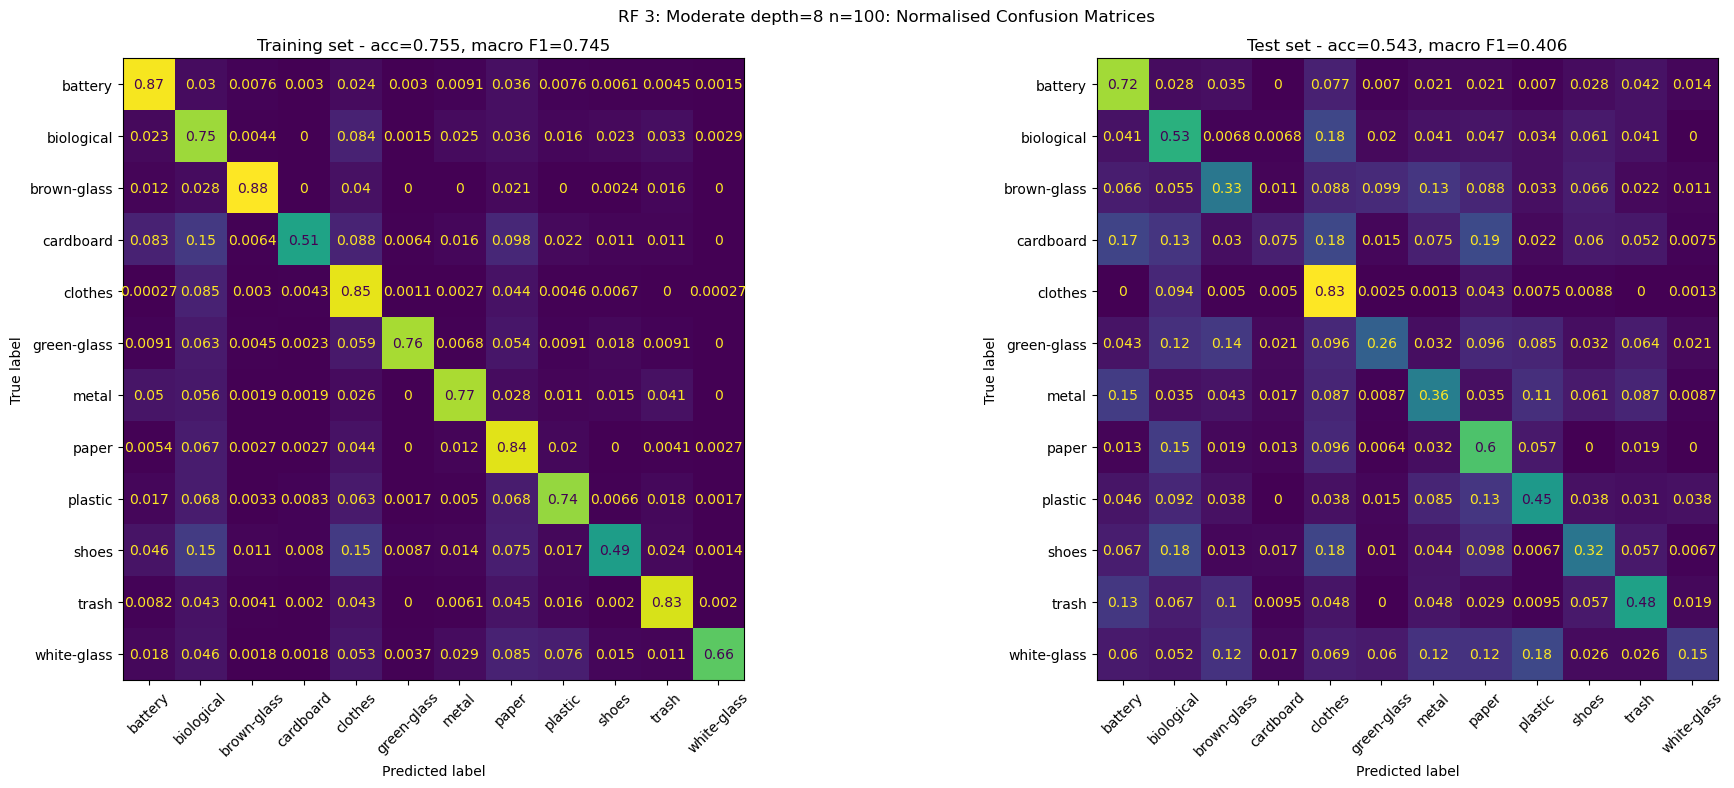

In [7]:
t0 = time.perf_counter()

rf3 = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    random_state=RANDOM_STATE,
    class_weight="balanced_subsample",
    n_jobs=-1,
).fit(X_train, Y_train)

train_time_3 = time.perf_counter() - t0

# Predictions
train_pred_3 = rf3.predict(X_train)

t0 = time.perf_counter()
test_pred_3 = rf3.predict(X_test)
infer_time_3 = time.perf_counter() - t0

result_3 = eval_model(
    Y_test,
    test_pred_3,
    class_list,
    model_name="RF 3: Moderate depth=8 n=100",
    y_train=Y_train,
    train_pred=train_pred_3,
    train_time=train_time_3,
    inference_time=infer_time_3,
)

## RF4 - Tuned

RF 4: Tuned depth=20 n=300
--------------------------
Training time     : 30.18s
Inference time    : 0.055s
Time per sample   : 0.024ms
--------------------------
              precision    recall  f1-score   support

     battery     0.6098    0.7042    0.6536       142
  biological     0.5946    0.1486    0.2378       148
 brown-glass     0.4048    0.1868    0.2556        91
   cardboard     0.8462    0.0821    0.1497       134
     clothes     0.5205    0.9987    0.6844       799
 green-glass     0.5862    0.1809    0.2764        94
       metal     0.4634    0.1652    0.2436       115
       paper     0.9565    0.2803    0.4335       157
     plastic     0.7167    0.3308    0.4526       130
       shoes     0.5171    0.4579    0.4857       297
       trash     0.7869    0.4571    0.5783       105
 white-glass     0.6410    0.2155    0.3226       116

    accuracy                         0.5498      2328
   macro avg     0.6370    0.3507    0.3978      2328
weighted avg     0.6027  

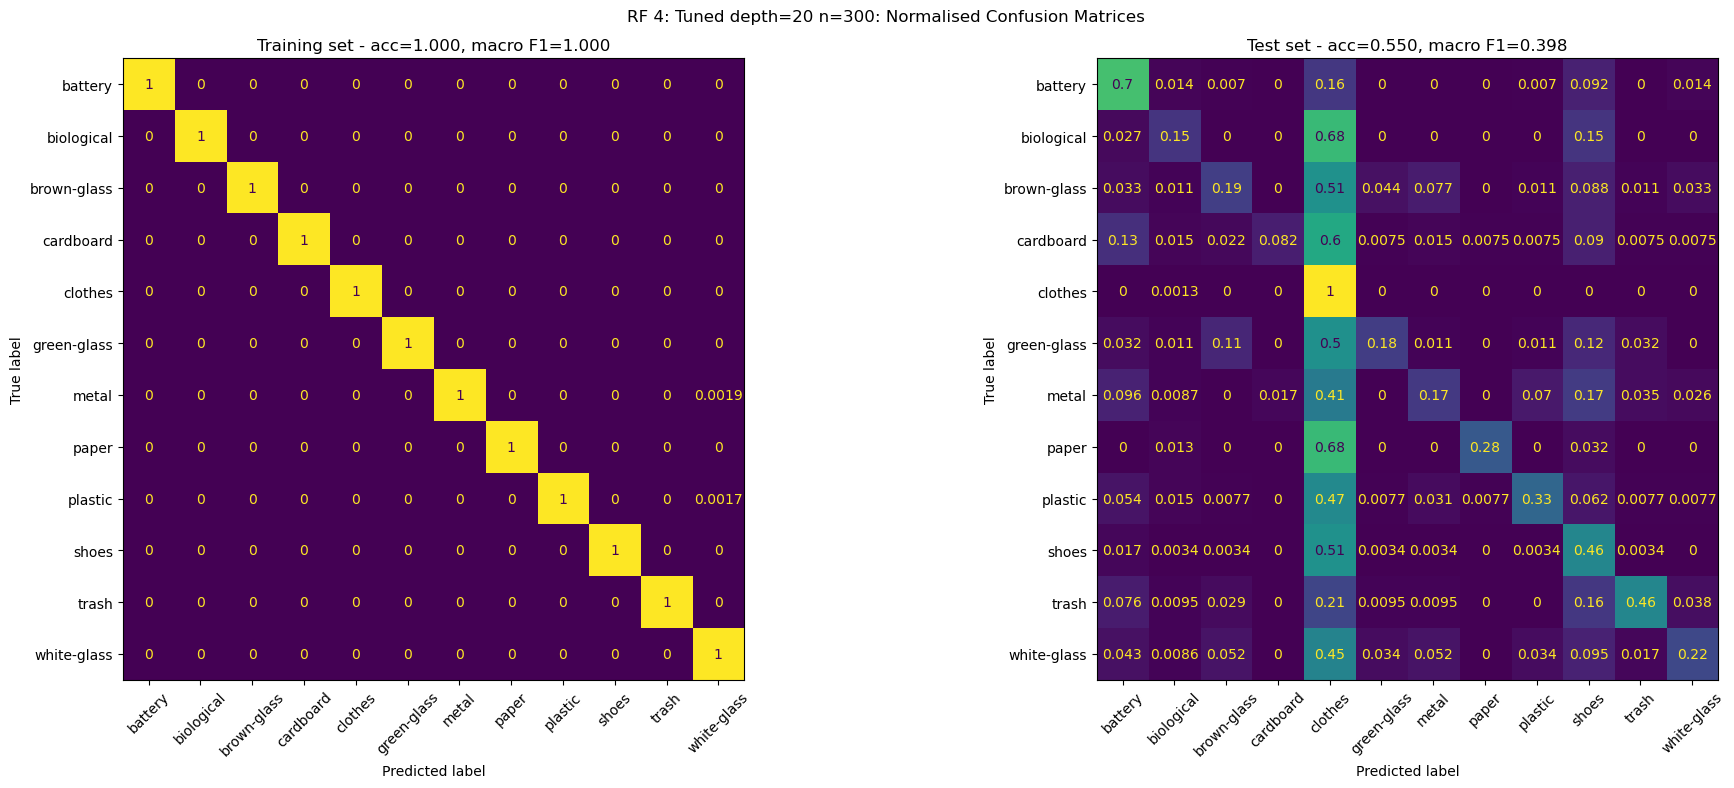

In [8]:
t0 = time.perf_counter()

rf4 = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    random_state=RANDOM_STATE,
    class_weight="balanced_subsample",
    n_jobs=-1,
).fit(X_train, Y_train)

train_time_4 = time.perf_counter() - t0

# Predictions
train_pred_4 = rf4.predict(X_train)

t0 = time.perf_counter()
test_pred_4 = rf4.predict(X_test)
infer_time_4 = time.perf_counter() - t0

result_4 = eval_model(
    Y_test,
    test_pred_4,
    class_list,
    model_name="RF 4: Tuned depth=20 n=300",
    y_train=Y_train,
    train_pred=train_pred_4,
    train_time=train_time_4,
    inference_time=infer_time_4,
)

## Compare 4 Random Forest Configurations

In [9]:
print(
    f'{"model":<45s}  {"acc":>6s}  {"macro F1":>9s}  '
    f'{"weighted F1":>11s}  {"train (s)":>10s}  {"infer (s)":>10s}'
)
print("-" * 110)

configs = [
    ("1. Shallow  (depth=4,  n=100, balanced)", result_1),
    ("2. Deep     (depth=32, n=100, balanced)", result_2),
    ("3. Moderate (depth=8,  n=100, balanced)", result_3),
    ("4. Tuned    (depth=20, n=300, balanced)", result_4),
]

for name, r in configs:
    print(
        f'{name:<45s}  '
        f'{r["test_accuracy"]:>6.3f}  '
        f'{r["test_macro_f1"]:>9.3f}  '
        f'{r["test_weighted_f1"]:>11.3f}  '
        f'{r["train_time"]:>10.2f}  '
        f'{r["inference_time"]:>10.3f}'
    )

model                                             acc   macro F1  weighted F1   train (s)   infer (s)
--------------------------------------------------------------------------------------------------------------
1. Shallow  (depth=4,  n=100, balanced)         0.463      0.284        0.419        3.51       0.024
2. Deep     (depth=32, n=100, balanced)         0.538      0.383        0.476       10.48       0.025
3. Moderate (depth=8,  n=100, balanced)         0.543      0.406        0.529        6.19       0.024
4. Tuned    (depth=20, n=300, balanced)         0.550      0.398        0.490       30.18       0.055


In [10]:
# Select best model
results = [result_1, result_2, result_3, result_4]
models = [rf1, rf2, rf3, rf4]
test_predictions = [test_pred_1, test_pred_2, test_pred_3, test_pred_4]
train_predictions = [train_pred_1, train_pred_2, train_pred_3, train_pred_4]

# Macro F1 is used because the dataset is imbalanced.
best_idx = int(np.argmax([r["test_macro_f1"] for r in results]))

best_rf = models[best_idx]
best_result = results[best_idx]
best_test_pred = test_predictions[best_idx]
best_train_pred = train_predictions[best_idx]

print("Best Random Forest model based on test macro F1:")
print(best_result["model_name"])
print(f'Test accuracy : {best_result["test_accuracy"]:.4f}')
print(f'Test macro F1 : {best_result["test_macro_f1"]:.4f}')

Best Random Forest model based on test macro F1:
RF 3: Moderate depth=8 n=100
Test accuracy : 0.5434
Test macro F1 : 0.4060


In [11]:
# Save the selected Random Forest result for final_comparison.ipynb.
save_metrics(
    best_result,
    PROJECT_ROOT / "random_forest" / "random_forest_metrics.json",
)

Saved metrics to: /home/n11902736/cab420/WasteClassification/random_forest/random_forest_metrics.json


## Failure Analysis

In [12]:
Y_prob = best_rf.predict_proba(X_test)

wrong_mask = best_test_pred != Y_test
wrong_idx = np.where(wrong_mask)[0]

pred_conf = Y_prob[wrong_idx, best_test_pred[wrong_idx]]
order = np.argsort(-pred_conf)

top_k = 12
selected = wrong_idx[order[:top_k]]

print(f"Top {top_k} high-confidence misclassifications:")
print()

for i in selected:
    print(
        f"  true: {class_list[Y_test[i]]:>12s}  "
        f"->  pred: {class_list[best_test_pred[i]]:>12s}  "
        f"(conf={Y_prob[i, best_test_pred[i]]:.3f})"
    )

Top 12 high-confidence misclassifications:

  true:  green-glass  ->  pred:        trash  (conf=0.860)
  true:        trash  ->  pred:      battery  (conf=0.717)
  true:        shoes  ->  pred:      battery  (conf=0.676)
  true:        trash  ->  pred:      battery  (conf=0.524)
  true:    cardboard  ->  pred:      battery  (conf=0.516)
  true:        trash  ->  pred:      battery  (conf=0.514)
  true:    cardboard  ->  pred:      battery  (conf=0.498)
  true:        shoes  ->  pred:      battery  (conf=0.478)
  true:  green-glass  ->  pred:        trash  (conf=0.454)
  true:        shoes  ->  pred:      battery  (conf=0.445)
  true:        trash  ->  pred:      battery  (conf=0.426)
  true:  green-glass  ->  pred:  brown-glass  (conf=0.407)


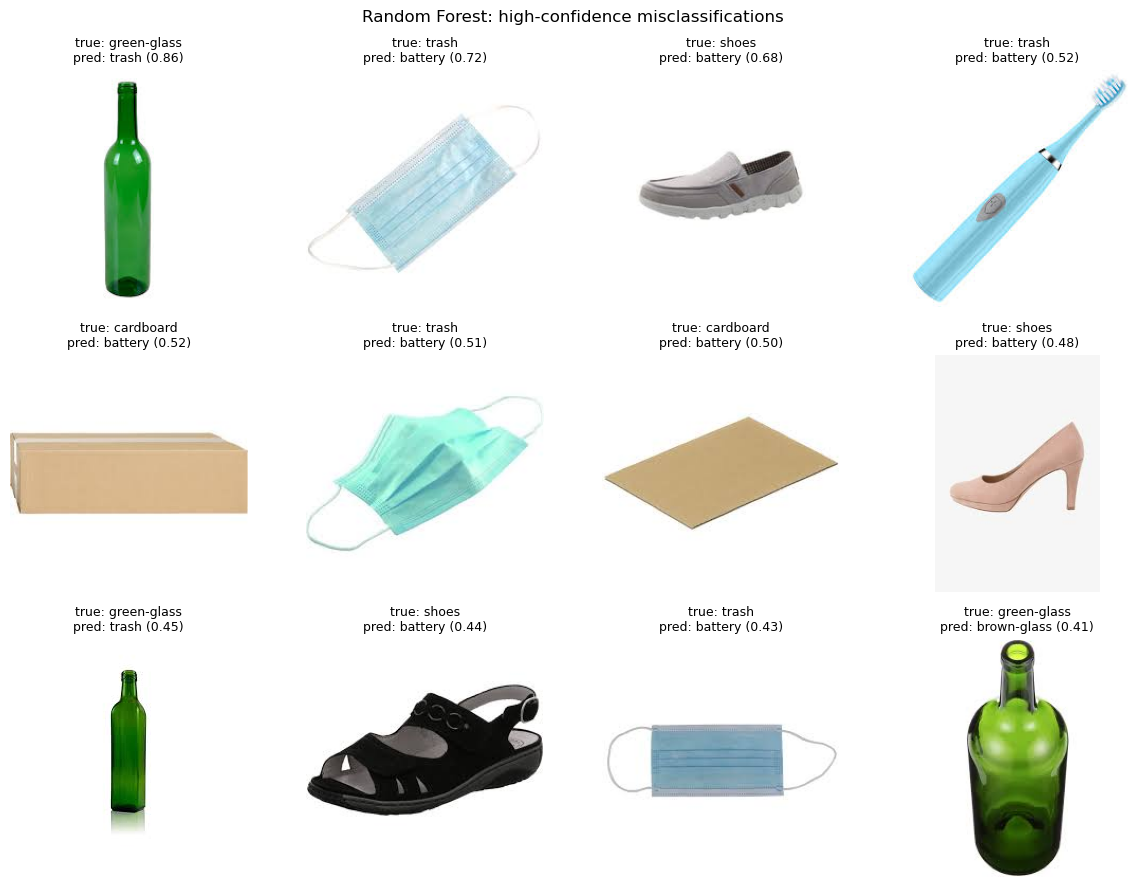

In [13]:
n_cols = 4
n_rows = int(np.ceil(len(selected) / n_cols))

fig = plt.figure(figsize=(12, 3 * n_rows))

for plot_i, image_i in enumerate(selected):
    ax = fig.add_subplot(n_rows, n_cols, plot_i + 1)

    img = Image.open(test_paths[image_i]).convert("RGB")
    ax.imshow(img)

    ax.set_title(
        f"true: {class_list[Y_test[image_i]]}\n"
        f"pred: {class_list[best_test_pred[image_i]]} "
        f"({Y_prob[image_i, best_test_pred[image_i]]:.2f})",
        fontsize=9,
    )

    ax.axis("off")

fig.suptitle("Random Forest: high-confidence misclassifications", fontsize=12)
plt.tight_layout()
plt.show()

In [14]:
fig.savefig(
    FIGURES_DIR / "random_forest_failure_cases.png",
    dpi=150,
    bbox_inches="tight",
)

print(f"Saved: {FIGURES_DIR / 'random_forest_failure_cases.png'}")

Saved: /home/n11902736/cab420/WasteClassification/random_forest_model/figures/random_forest_failure_cases.png
